In [1]:
from google.colab import files

uploaded = files.upload()

Saving WLD_2024_FINDEX_v02_M_CSV.zip to WLD_2024_FINDEX_v02_M_CSV.zip


In [2]:
import zipfile
import os

zip_file = "WLD_2024_FINDEX_v02_M_CSV.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("findex_data")

os.listdir("findex_data")

['findex_microdata_2025_labelled_update112425.csv']

In [3]:
import pandas as pd

file_path = "findex_data/findex_microdata_2025_labelled_update112425.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 144090
Columns: 199


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,...,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,0.927315,1,53,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,1.383884,2,48,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,1.323486,1,40,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Kuwait,KWT,High income,3950546,111113432,1.475693,1,25,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,2024,Turkiye,TUR,Europe & Central Asia (excluding high income),66691005,111115194,0.651801,2,72,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


In [4]:
# Variables potentially relevant to our research question
variables = [
    "economy",
    "regionwb",
    "female",
    "age",
    "educ",
    "inc_q",
    "emp_in",
    "urbanicity",
    "account_fin",
    "account_mob",
    "account",
    "dig_account",
    "internet_use",
    "saved",
    "borrowed",
    "anydigpayment"
]

# Confirm they exist
for var in variables:
    if var in df.columns:
        print(f"\n--- {var} ---")
        print(df[var].value_counts(dropna=False).head(15))
    else:
        print(f"\n{var}: NOT FOUND")


--- economy ---
economy
China           4020
India           3000
Nicaragua       1130
Indonesia       1068
Eswatini        1051
Mexico          1050
Canada          1024
Lesotho         1020
Saudi Arabia    1018
Bahrain         1015
Morocco         1014
Lithuania       1012
Cyprus          1010
Panama          1010
Lebanon         1010
Name: count, dtype: int64

--- regionwb ---
regionwb
High income                                           46167
Sub-Saharan Africa (excluding high income)            35093
Europe & Central Asia (excluding high income)         18000
Latin America & Caribbean (excluding high income)     15696
East Asia & Pacific (excluding high income)           12088
Middle East & North Africa (excluding high income)    10046
South Asia                                             7000
Name: count, dtype: int64

--- female ---
female
1    75580
2    68510
Name: count, dtype: int64

--- age ---
age
30    4488
40    4142
35    3921
25    3744
20    3372
50    3364
45    3

In [5]:
# Check mobile-money coverage by country
mobile_coverage = (
    df.groupby(["economy", "regionwb"])["account_mob"]
      .agg(
          respondents="size",
          non_missing="count",
          mobile_money_users=lambda x: (x == 1).sum()
      )
      .reset_index()
)

mobile_coverage["coverage_pct"] = (
    mobile_coverage["non_missing"] /
    mobile_coverage["respondents"] * 100
)

mobile_coverage["adoption_pct"] = (
    mobile_coverage["mobile_money_users"] /
    mobile_coverage["non_missing"] * 100
)

mobile_coverage.sort_values(
    "adoption_pct",
    ascending=False
).head(30)

,economy,regionwb,respondents,non_missing,mobile_money_users,coverage_pct,adoption_pct
65,Kenya,Sub-Saharan Africa (excluding high income),1000,1000,893,100.0,89.300000
47,Ghana,Sub-Saharan Africa (excluding high income),1000,1000,818,100.0,81.800000
138,Zambia,Sub-Saharan Africa (excluding high income),1000,1000,802,100.0,80.200000
129,Uganda,Sub-Saharan Africa (excluding high income),1000,1000,744,100.0,74.400000
110,Senegal,Sub-Saharan Africa (excluding high income),1000,1000,726,100.0,72.600000
43,Gabon,Sub-Saharan Africa (excluding high income),1000,1000,702,100.0,70.200000
86,Mongolia,East Asia & Pacific (excluding high income),1000,1000,637,100.0,63.700000
14,Botswana,Sub-Saharan Africa (excluding high income),1000,1000,630,100.0,63.000000
113,Singapore,High income,1000,1000,626,100.0,62.600000
19,Cameroon,Sub-Saharan Africa (excluding high income),1000,1000,613,100.0,61.300000


In [6]:
# Keep respondents from World Bank regions explicitly excluding high-income economies
developing = df[
    df["regionwb"].str.contains("excluding high income", case=False, na=False)
].copy()

# Keep only respondents for whom mobile-money account status is observed
mobile_sample = developing[
    developing["account_mob"].notna()
].copy()

print("Developing-economy respondents:", len(developing))
print("Respondents with mobile-money data:", len(mobile_sample))
print("Number of economies:", mobile_sample["economy"].nunique())

print("\nRegions:")
print(mobile_sample["regionwb"].value_counts())

print("\nMobile-money outcome:")
print(mobile_sample["account_mob"].value_counts())

Developing-economy respondents: 90923
Respondents with mobile-money data: 70893
Number of economies: 71

Regions:
regionwb
Sub-Saharan Africa (excluding high income)            34093
Latin America & Caribbean (excluding high income)     14693
East Asia & Pacific (excluding high income)            8068
Middle East & North Africa (excluding high income)     8039
Europe & Central Asia (excluding high income)          6000
Name: count, dtype: int64

Mobile-money outcome:
account_mob
0.0    45897
1.0    24996
Name: count, dtype: int64


In [7]:
# Mobile-money ownership by internet use
internet_mobile = pd.crosstab(
    mobile_sample["internet_use"],
    mobile_sample["account_mob"],
    normalize="index"
) * 100

print(internet_mobile)

# Also show sample sizes
print("\nSample sizes:")
print(
    mobile_sample.groupby("internet_use")["account_mob"]
    .count()
)

account_mob         0.0        1.0
internet_use                      
0             76.293399  23.706601
1             58.526055  41.473945

Sample sizes:
internet_use
0    24799
1    46094
Name: account_mob, dtype: int64


In [8]:
controls = [
    "female",
    "age",
    "educ",
    "inc_q",
    "emp_in",
    "urbanicity"
]

for var in controls:
    print(f"\n--- {var} ---")
    print(mobile_sample[var].value_counts(dropna=False).sort_index())


--- female ---
female
1    38744
2    32149
Name: count, dtype: int64

--- age ---
age
15     1403
16     1363
17     1444
18     2169
19     1706
       ... 
96        2
97        2
98        1
99       14
100      45
Name: count, Length: 86, dtype: int64

--- educ ---
educ
1.0    25987
2.0    36496
3.0     8068
NaN      342
Name: count, dtype: int64

--- inc_q ---
inc_q
1.0    11741
2.0    12097
3.0    13206
4.0    14559
5.0    18270
NaN     1020
Name: count, dtype: int64

--- emp_in ---
emp_in
1.0    43931
2.0    26962
Name: count, dtype: int64

--- urbanicity ---
urbanicity
1.0    42521
2.0    28009
NaN      363
Name: count, dtype: int64


In [9]:
for var in ["female", "educ", "emp_in", "urbanicity", "inc_q"]:
    print(f"{var}: {sorted(mobile_sample[var].dropna().unique())}")

female: [np.int64(1), np.int64(2)]
educ: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
emp_in: [np.float64(1.0), np.float64(2.0)]
urbanicity: [np.float64(1.0), np.float64(2.0)]
inc_q: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [10]:
# Create analysis-friendly variables
analysis = mobile_sample.copy()

analysis["female_binary"] = (analysis["female"] == 1).astype(int)
analysis["urban_binary"] = (analysis["urbanicity"] == 2).astype(int)
analysis["employed_binary"] = (analysis["emp_in"] == 1).astype(int)

# Give categorical variables readable labels
analysis["education"] = analysis["educ"].map({
    1: "Primary or less",
    2: "Secondary",
    3: "Tertiary or more"
})

analysis["income_quintile"] = analysis["inc_q"]

# Check our recoding
print(analysis[
    [
        "female", "female_binary",
        "urbanicity", "urban_binary",
        "emp_in", "employed_binary",
        "educ", "education",
        "inc_q", "income_quintile"
    ]
].head(10))

    female  female_binary  urbanicity  urban_binary  emp_in  employed_binary  \
0        1              1         1.0             0     1.0                1   
2        1              1         1.0             0     1.0                1   
4        2              0         2.0             1     2.0                0   
6        1              1         1.0             0     1.0                1   
12       2              0         1.0             0     1.0                1   
14       2              0         2.0             1     1.0                1   
15       2              0         1.0             0     1.0                1   
18       1              1         1.0             0     1.0                1   
20       1              1         1.0             0     1.0                1   
21       2              0         1.0             0     1.0                1   

    educ         education  inc_q  income_quintile  
0    1.0   Primary or less    5.0              5.0  
2    1.0   Pr

In [11]:
import statsmodels.formula.api as smf

# Keep complete observations for variables used in the model
model_data = analysis[
    [
        "account_mob",
        "internet_use",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary"
    ]
].dropna().copy()

print("Regression sample size:", len(model_data))

# Logistic regression
model1 = smf.logit(
    formula="""
        account_mob ~ internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
    """,
    data=model_data
).fit()

print(model1.summary())

Regression sample size: 69549
Optimization terminated successfully.
         Current function value: 0.586178
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            account_mob   No. Observations:                69549
Model:                          Logit   Df Residuals:                    69537
Method:                           MLE   Df Model:                           11
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                 0.09397
Time:                        22:09:31   Log-Likelihood:                -40768.
converged:                       True   LL-Null:                       -44996.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         

In [13]:
import numpy as np

In [14]:
# Add economy back into the regression dataset
model_data2 = analysis[
    [
        "account_mob",
        "internet_use",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy"
    ]
].dropna().copy()

print("Regression sample size:", len(model_data2))
print("Economies:", model_data2["economy"].nunique())

# Logistic regression with economy fixed effects
model2 = smf.logit(
    formula="""
        account_mob ~ internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=model_data2
).fit(maxiter=200)

# Print only our main variables instead of 70+ country coefficients
variables_of_interest = [
    "internet_use",
    "female_binary",
    "age",
    "employed_binary",
    "urban_binary"
]

results = pd.DataFrame({
    "Coefficient": model2.params[variables_of_interest],
    "P-value": model2.pvalues[variables_of_interest],
    "Odds Ratio": np.exp(model2.params[variables_of_interest])
})

print(results)

Regression sample size: 69549
Economies: 70
Optimization terminated successfully.
         Current function value: 0.448735
         Iterations 8
                 Coefficient        P-value  Odds Ratio
internet_use        1.290010   0.000000e+00    3.632823
female_binary      -0.215469   5.502467e-26    0.806163
age                -0.007132   9.991751e-25    0.992893
employed_binary     0.807953  4.086797e-279    2.243311
urban_binary        0.172336   7.184472e-15    1.188077


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os
import shutil

project_dir = "/content/drive/MyDrive/Global_Findex_Mobile_Money_Project"
data_dir = os.path.join(project_dir, "data")
outputs_dir = os.path.join(project_dir, "outputs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

source_zip = "/content/WLD_2024_FINDEX_v02_M_CSV.zip"
destination_zip = os.path.join(data_dir, "WLD_2024_FINDEX_v02_M_CSV.zip")

if os.path.exists(source_zip):
    shutil.copy2(source_zip, destination_zip)

print("Project folder:", project_dir)
print("Dataset saved:", os.path.exists(destination_zip))
print("Files in data folder:", os.listdir(data_dir))

Project folder: /content/drive/MyDrive/Global_Findex_Mobile_Money_Project
Dataset saved: True
Files in data folder: ['WLD_2024_FINDEX_v02_M_CSV.zip']


In [17]:
import numpy as np
import statsmodels.formula.api as smf

# Build regression dataset
model_data2 = analysis[
    [
        "account_mob",
        "internet_use",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy"
    ]
].dropna().copy()

print("Regression sample size:", len(model_data2))
print("Economies:", model_data2["economy"].nunique())

# Logistic regression with country fixed effects
model2 = smf.logit(
    formula="""
        account_mob ~ internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=model_data2
).fit(maxiter=200)

# Display the variables we're most interested in
variables_of_interest = [
    "internet_use",
    "female_binary",
    "age",
    "employed_binary",
    "urban_binary"
]

results = pd.DataFrame({
    "Coefficient": model2.params[variables_of_interest],
    "P-value": model2.pvalues[variables_of_interest],
    "Odds Ratio": np.exp(model2.params[variables_of_interest])
})

print("\nKey results:")
print(results)

Regression sample size: 69549
Economies: 70
Optimization terminated successfully.
         Current function value: 0.448735
         Iterations 8

Key results:
                 Coefficient        P-value  Odds Ratio
internet_use        1.290010   0.000000e+00    3.632823
female_binary      -0.215469   5.502467e-26    0.806163
age                -0.007132   9.991751e-25    0.992893
employed_binary     0.807953  4.086797e-279    2.243311
urban_binary        0.172336   7.184472e-15    1.188077


In [18]:
all_economies = set(mobile_sample["economy"].dropna().unique())
regression_economies = set(model_data2["economy"].dropna().unique())

missing_economies = all_economies - regression_economies

print("Economies excluded from regression:")
print(missing_economies)

if missing_economies:
    for country in missing_economies:
        print(f"\n--- {country} ---")
        country_data = analysis[analysis["economy"] == country]

        print(
            country_data[
                [
                    "account_mob",
                    "internet_use",
                    "female_binary",
                    "age",
                    "education",
                    "income_quintile",
                    "employed_binary",
                    "urban_binary"
                ]
            ].isna().sum()
        )

Economies excluded from regression:
{'Lesotho'}

--- Lesotho ---
account_mob           0
internet_use          0
female_binary         0
age                   0
education            18
income_quintile    1020
employed_binary       0
urban_binary          0
dtype: int64


In [19]:
# Inspect World Bank survey weights
print(mobile_sample["wgt"].describe())

print("\nMissing weights:")
print(mobile_sample["wgt"].isna().sum())

print("\nWeight totals by economy (first 15):")
print(
    mobile_sample.groupby("economy")["wgt"]
    .agg(["count", "sum", "min", "max"])
    .head(15)
)

count    70893.000000
mean         1.000000
std          0.749045
min          0.078167
25%          0.459864
50%          0.791776
75%          1.304816
max          7.549079
Name: wgt, dtype: float64

Missing weights:
0

Weight totals by economy (first 15):
                  count     sum       min       max
economy                                            
Argentina          1000  1000.0  0.302169  3.323854
Armenia            1000  1000.0  0.275385  2.746864
Belize              509   509.0  0.234248  3.279479
Benin              1000  1000.0  0.202265  3.719600
Bolivia            1000  1000.0  0.254129  2.419665
Botswana           1000  1000.0  0.186104  2.716437
Brazil             1000  1000.0  0.300686  3.006860
Burkina Faso       1000  1000.0  0.236766  2.341952
Cambodia           1000  1000.0  0.203102  3.189908
Cameroon           1000  1000.0  0.244830  2.274175
Chad               1000  1000.0  0.155096  3.101919
Colombia           1000  1000.0  0.327211  2.538198
Comoros     

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

weighted_data = analysis[
    [
        "account_mob",
        "internet_use",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy",
        "wgt"
    ]
].dropna().copy()

print("Weighted regression sample:", len(weighted_data))
print("Economies:", weighted_data["economy"].nunique())

model3 = smf.glm(
    formula="""
        account_mob ~ internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=weighted_data,
    family=sm.families.Binomial(),
    freq_weights=weighted_data["wgt"]
).fit()

variables_of_interest = [
    "internet_use",
    "female_binary",
    "age",
    "employed_binary",
    "urban_binary"
]

weighted_results = pd.DataFrame({
    "Coefficient": model3.params[variables_of_interest],
    "P-value": model3.pvalues[variables_of_interest],
    "Odds Ratio": np.exp(model3.params[variables_of_interest])
})

print("\nWeighted country-fixed-effects results:")
print(weighted_results)

Weighted regression sample: 69549
Economies: 70

Weighted country-fixed-effects results:
                 Coefficient        P-value  Odds Ratio
internet_use        1.270063   0.000000e+00    3.561076
female_binary      -0.207223   9.715266e-25    0.812838
age                -0.004315   1.693829e-10    0.995694
employed_binary     0.798085  2.589523e-278    2.221283
urban_binary        0.185298   7.881175e-17    1.203577


In [21]:
model_gender = smf.glm(
    formula="""
        account_mob ~ internet_use * female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=weighted_data,
    family=sm.families.Binomial(),
    freq_weights=weighted_data["wgt"]
).fit()

gender_terms = [
    "internet_use",
    "female_binary",
    "internet_use:female_binary"
]

gender_results = pd.DataFrame({
    "Coefficient": model_gender.params[gender_terms],
    "P-value": model_gender.pvalues[gender_terms],
    "Odds Ratio": np.exp(model_gender.params[gender_terms])
})

print(gender_results)

                            Coefficient        P-value  Odds Ratio
internet_use                   1.297243  8.508115e-299    3.659193
female_binary                 -0.172108   3.314325e-07    0.841889
internet_use:female_binary    -0.054273   1.935759e-01    0.947173


In [22]:
model_income = smf.glm(
    formula="""
        account_mob ~ internet_use * C(income_quintile)
        + female_binary
        + age
        + C(education)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=weighted_data,
    family=sm.families.Binomial(),
    freq_weights=weighted_data["wgt"]
).fit()

# Pull out internet/income terms
income_terms = [
    term for term in model_income.params.index
    if "internet_use" in term or "income_quintile" in term
]

income_results = pd.DataFrame({
    "Coefficient": model_income.params[income_terms],
    "P-value": model_income.pvalues[income_terms],
    "Odds Ratio": np.exp(model_income.params[income_terms])
})

print(income_results)

                                        Coefficient        P-value  Odds Ratio
C(income_quintile)[T.2.0]                  0.323336   1.591891e-10    1.381730
C(income_quintile)[T.3.0]                  0.545981   2.463915e-26    1.726300
C(income_quintile)[T.4.0]                  0.715073   3.944347e-42    2.044336
C(income_quintile)[T.5.0]                  0.725907   4.192260e-37    2.066605
internet_use                               1.366275  8.528814e-150    3.920718
internet_use:C(income_quintile)[T.2.0]    -0.059461   3.757448e-01    0.942273
internet_use:C(income_quintile)[T.3.0]    -0.206055   2.046150e-03    0.813788
internet_use:C(income_quintile)[T.4.0]    -0.174523   9.302800e-03    0.839858
internet_use:C(income_quintile)[T.5.0]    -0.017608   8.019902e-01    0.982546


In [23]:
predictions = []

for q in range(1, 6):
    for internet in [0, 1]:

        temp = weighted_data.copy()

        # Counterfactual:
        # give everyone the same income quintile and internet status
        temp["income_quintile"] = float(q)
        temp["internet_use"] = internet

        # Predict for every respondent while preserving their
        # age, gender, education, employment, urbanicity and country
        probs = model_income.predict(temp)

        # Weighted average predicted probability
        avg_prob = np.average(
            probs,
            weights=temp["wgt"]
        )

        predictions.append({
            "Income Quintile": q,
            "Internet Use": internet,
            "Adjusted Probability": avg_prob
        })

pred_df = pd.DataFrame(predictions)

table = pred_df.pivot(
    index="Income Quintile",
    columns="Internet Use",
    values="Adjusted Probability"
)

table.columns = ["No Internet", "Internet"]
table["Difference"] = table["Internet"] - table["No Internet"]

# Convert to percentages
table = table * 100

print(table.round(2))

                 No Internet  Internet  Difference
Income Quintile                                   
1                      15.95     34.07       18.12
2                      19.56     38.25       18.70
3                      22.31     39.48       17.17
4                      24.54     42.76       18.22
5                      24.69     45.53       20.84


In [24]:
model_urban = smf.glm(
    formula="""
        account_mob ~ internet_use * urban_binary
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + C(economy)
    """,
    data=weighted_data,
    family=sm.families.Binomial(),
    freq_weights=weighted_data["wgt"]
).fit()

urban_terms = [
    "internet_use",
    "urban_binary",
    "internet_use:urban_binary"
]

urban_results = pd.DataFrame({
    "Coefficient": model_urban.params[urban_terms],
    "P-value": model_urban.pvalues[urban_terms],
    "Odds Ratio": np.exp(model_urban.params[urban_terms])
})

print(urban_results)

                           Coefficient   P-value  Odds Ratio
internet_use                  1.248371  0.000000    3.484661
urban_binary                  0.138471  0.000549    1.148516
internet_use:urban_binary     0.065650  0.159582    1.067853


In [25]:
# Find every variable whose name mentions phone or mobile
phone_vars = [
    col for col in df.columns
    if "phone" in col.lower() or "mobile" in col.lower()
]

print("Phone/mobile-related variables:")
for col in phone_vars:
    print(col)

Phone/mobile-related variables:


In [26]:
keywords = [
    "cell",
    "device",
    "sim",
    "connect",
    "digital",
    "internet",
    "tel",
    "own"
]

for keyword in keywords:
    matches = [col for col in df.columns if keyword.lower() in col.lower()]

    print(f"\n--- {keyword} ---")
    print(matches)


--- cell ---
[]

--- device ---
[]

--- sim ---
[]

--- connect ---
[]

--- digital ---
[]

--- internet ---
['internet_use']

--- tel ---
[]

--- own ---
[]


In [27]:
print("con1 exists:", "con1" in df.columns)

if "con1" in df.columns:
    print("\nOverall values:")
    print(df["con1"].value_counts(dropna=False))

    print("\nValues in our mobile-money sample:")
    print(mobile_sample["con1"].value_counts(dropna=False))

    print("\nCoverage by region:")
    print(
        mobile_sample.groupby("regionwb")["con1"]
        .agg(["count", "size"])
    )

con1 exists: True

Overall values:
con1
1    129126
2     14862
4        61
3        41
Name: count, dtype: int64

Values in our mobile-money sample:
con1
1    60665
2    10190
4       21
3       17
Name: count, dtype: int64

Coverage by region:
                                                    count   size
regionwb                                                        
East Asia & Pacific (excluding high income)          8068   8068
Europe & Central Asia (excluding high income)        6000   6000
Latin America & Caribbean (excluding high income)   14693  14693
Middle East & North Africa (excluding high income)   8039   8039
Sub-Saharan Africa (excluding high income)          34093  34093


In [28]:
print("con1 values:")
print(df["con1"].value_counts(dropna=False))

# See how con1 relates to internet use
print("\ncon1 × internet_use:")
print(pd.crosstab(
    mobile_sample["con1"],
    mobile_sample["internet_use"],
    margins=True
))

# See mobile-money ownership by con1
print("\nMobile-money ownership by con1:")
print(
    mobile_sample.groupby("con1")["account_mob"]
    .agg(["count", "mean"])
)

con1 values:
con1
1    129126
2     14862
4        61
3        41
Name: count, dtype: int64

con1 × internet_use:
internet_use      0      1    All
con1                             
1             16509  44156  60665
2              8267   1923  10190
3                10      7     17
4                13      8     21
All           24799  46094  70893

Mobile-money ownership by con1:
      count      mean
con1                 
1     60665  0.395154
2     10190  0.100098
3        17  0.176471
4        21  0.047619


In [29]:
# Create verified phone-ownership variable
analysis["phone_owner"] = np.where(
    analysis["con1"] == 1, 1,
    np.where(analysis["con1"] == 2, 0, np.nan)
)

# Build regression sample
phone_data = analysis[
    [
        "account_mob",
        "internet_use",
        "phone_owner",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy",
        "wgt"
    ]
].dropna().copy()

print("Regression sample:", len(phone_data))
print("Economies:", phone_data["economy"].nunique())

model_phone = smf.glm(
    formula="""
        account_mob ~ internet_use
        + phone_owner
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=phone_data,
    family=sm.families.Binomial(),
    freq_weights=phone_data["wgt"]
).fit()

phone_results = pd.DataFrame({
    "Coefficient": model_phone.params[
        ["internet_use", "phone_owner"]
    ],
    "P-value": model_phone.pvalues[
        ["internet_use", "phone_owner"]
    ],
    "Odds Ratio": np.exp(
        model_phone.params[["internet_use", "phone_owner"]]
    )
})

print("\nInternet + phone ownership:")
print(phone_results)

Regression sample: 69517
Economies: 70

Internet + phone ownership:
              Coefficient        P-value  Odds Ratio
internet_use     0.988345  1.113690e-249    2.686785
phone_owner      1.675409   0.000000e+00    5.340981


In [30]:
connectivity_predictions = []

for phone in [0, 1]:
    for internet in [0, 1]:

        temp = phone_data.copy()

        # Set everyone to the same connectivity profile
        temp["phone_owner"] = phone
        temp["internet_use"] = internet

        # Predict while preserving each respondent's
        # demographics and country
        probs = model_phone.predict(temp)

        # Survey-weighted average predicted probability
        avg_prob = np.average(
            probs,
            weights=temp["wgt"]
        )

        connectivity_predictions.append({
            "Phone Owner": "Yes" if phone == 1 else "No",
            "Internet User": "Yes" if internet == 1 else "No",
            "Adjusted Probability (%)": avg_prob * 100
        })

connectivity_table = pd.DataFrame(connectivity_predictions)

print(connectivity_table.round(2))

  Phone Owner Internet User  Adjusted Probability (%)
0          No            No                      9.21
1          No           Yes                     18.08
2         Yes            No                     26.69
3         Yes           Yes                     41.67


In [31]:
# Actual number of respondents in each connectivity profile
profile_counts = pd.crosstab(
    phone_data["phone_owner"],
    phone_data["internet_use"]
)

profile_counts.index = ["No Phone", "Phone"]
profile_counts.columns = ["No Internet", "Internet"]

print("Actual respondent counts:")
print(profile_counts)

print("\nPercent of regression sample:")
print((profile_counts / profile_counts.values.sum() * 100).round(2))

Actual respondent counts:
          No Internet  Internet
No Phone         8094      1880
Phone           16073     43470

Percent of regression sample:
          No Internet  Internet
No Phone        11.64      2.70
Phone           23.12     62.53


In [32]:
regional_results = []

for region in phone_data["regionwb"].unique():

    region_data = phone_data[
        phone_data["regionwb"] == region
    ].copy()

    # Only run if both outcome values and connectivity values vary
    if (
        region_data["account_mob"].nunique() > 1
        and region_data["internet_use"].nunique() > 1
        and region_data["phone_owner"].nunique() > 1
    ):

        regional_model = smf.glm(
            formula="""
                account_mob ~ internet_use
                + phone_owner
                + female_binary
                + age
                + C(education)
                + C(income_quintile)
                + employed_binary
                + urban_binary
                + C(economy)
            """,
            data=region_data,
            family=sm.families.Binomial(),
            freq_weights=region_data["wgt"]
        ).fit()

        regional_results.append({
            "Region": region,
            "N": len(region_data),
            "Internet OR": np.exp(regional_model.params["internet_use"]),
            "Internet p": regional_model.pvalues["internet_use"],
            "Phone OR": np.exp(regional_model.params["phone_owner"]),
            "Phone p": regional_model.pvalues["phone_owner"]
        })

regional_table = pd.DataFrame(regional_results)

print(
    regional_table[
        ["Region", "N", "Internet OR", "Internet p", "Phone OR", "Phone p"]
    ].to_string(index=False)
)

KeyError: 'regionwb'

In [33]:
phone_data = analysis[
    [
        "account_mob",
        "internet_use",
        "phone_owner",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy",
        "regionwb",
        "wgt"
    ]
].dropna().copy()

print("Regression sample:", len(phone_data))
print("Economies:", phone_data["economy"].nunique())
print(phone_data["regionwb"].value_counts())

Regression sample: 69517
Economies: 70
regionwb
Sub-Saharan Africa (excluding high income)            32882
Latin America & Caribbean (excluding high income)     14582
East Asia & Pacific (excluding high income)            8050
Middle East & North Africa (excluding high income)     8020
Europe & Central Asia (excluding high income)          5983
Name: count, dtype: int64


In [34]:
regional_results = []

In [35]:
regional_results = []

for region in phone_data["regionwb"].unique():

    region_data = phone_data[
        phone_data["regionwb"] == region
    ].copy()

    if (
        region_data["account_mob"].nunique() > 1
        and region_data["internet_use"].nunique() > 1
        and region_data["phone_owner"].nunique() > 1
    ):

        regional_model = smf.glm(
            formula="""
                account_mob ~ internet_use
                + phone_owner
                + female_binary
                + age
                + C(education)
                + C(income_quintile)
                + employed_binary
                + urban_binary
                + C(economy)
            """,
            data=region_data,
            family=sm.families.Binomial(),
            freq_weights=region_data["wgt"]
        ).fit()

        regional_results.append({
            "Region": region,
            "N": len(region_data),
            "Internet OR": np.exp(regional_model.params["internet_use"]),
            "Internet p": regional_model.pvalues["internet_use"],
            "Phone OR": np.exp(regional_model.params["phone_owner"]),
            "Phone p": regional_model.pvalues["phone_owner"]
        })

regional_table = pd.DataFrame(regional_results)

print(
    regional_table[
        ["Region", "N", "Internet OR", "Internet p", "Phone OR", "Phone p"]
    ].to_string(index=False)
)

                                            Region     N  Internet OR    Internet p  Phone OR      Phone p
 Latin America & Caribbean (excluding high income) 14582     3.678873  9.562738e-27  2.864276 3.798187e-15
        Sub-Saharan Africa (excluding high income) 32882     2.635031 8.137147e-186  5.582408 0.000000e+00
     Europe & Central Asia (excluding high income)  5983    10.486050  2.832706e-20  1.785915 6.262118e-03
       East Asia & Pacific (excluding high income)  8050     3.600737  1.228337e-18  6.204612 8.284848e-12
Middle East & North Africa (excluding high income)  8020     3.276414  1.273081e-10  1.894452 1.090469e-03


In [36]:
model_clustered = smf.glm(
    formula="""
        account_mob ~ internet_use
        + phone_owner
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=phone_data,
    family=sm.families.Binomial(),
    freq_weights=phone_data["wgt"]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": phone_data["economy"]}
)

clustered_results = pd.DataFrame({
    "Coefficient": model_clustered.params[
        ["internet_use", "phone_owner"]
    ],
    "Clustered SE": model_clustered.bse[
        ["internet_use", "phone_owner"]
    ],
    "P-value": model_clustered.pvalues[
        ["internet_use", "phone_owner"]
    ],
    "Odds Ratio": np.exp(
        model_clustered.params[["internet_use", "phone_owner"]]
    )
})

print(clustered_results)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


              Coefficient  Clustered SE       P-value  Odds Ratio
internet_use     0.988345      0.058892  3.282490e-63    2.686785
phone_owner      1.675409      0.106505  9.307369e-56    5.340981


In [37]:
model_unweighted_clustered = smf.glm(
    formula="""
        account_mob ~ internet_use
        + phone_owner
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=phone_data,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": phone_data["economy"]}
)

unweighted_clustered_results = pd.DataFrame({
    "Coefficient": model_unweighted_clustered.params[
        ["internet_use", "phone_owner"]
    ],
    "Clustered SE": model_unweighted_clustered.bse[
        ["internet_use", "phone_owner"]
    ],
    "P-value": model_unweighted_clustered.pvalues[
        ["internet_use", "phone_owner"]
    ],
    "Odds Ratio": np.exp(
        model_unweighted_clustered.params[["internet_use", "phone_owner"]]
    )
})

print(unweighted_clustered_results)

              Coefficient  Clustered SE        P-value  Odds Ratio
internet_use     1.033605      0.047106  1.031870e-106    2.811181
phone_owner      1.618852      0.097455   5.781273e-62    5.047294


In [38]:
# Build sample for overall account ownership
account_data = analysis[
    [
        "account",
        "internet_use",
        "phone_owner",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy",
        "regionwb",
        "wgt"
    ]
].dropna().copy()

print("Sample size:", len(account_data))
print("Economies:", account_data["economy"].nunique())

# Weighted logistic model with country fixed effects
model_account = smf.glm(
    formula="""
        account ~ internet_use
        + phone_owner
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=account_data,
    family=sm.families.Binomial(),
    freq_weights=account_data["wgt"]
).fit()

account_results = pd.DataFrame({
    "Coefficient": model_account.params[
        ["internet_use", "phone_owner"]
    ],
    "P-value": model_account.pvalues[
        ["internet_use", "phone_owner"]
    ],
    "Odds Ratio": np.exp(
        model_account.params[["internet_use", "phone_owner"]]
    )
})

print("\nOverall account ownership:")
print(account_results)

Sample size: 69517
Economies: 70

Overall account ownership:
              Coefficient        P-value  Odds Ratio
internet_use     0.839691  5.333767e-243    2.315650
phone_owner      1.152866   0.000000e+00    3.167257


In [39]:
fin_data = analysis[
    [
        "account_fin",
        "internet_use",
        "phone_owner",
        "female_binary",
        "age",
        "education",
        "income_quintile",
        "employed_binary",
        "urban_binary",
        "economy",
        "wgt"
    ]
].dropna().copy()

model_fin = smf.glm(
    formula="""
        account_fin ~ internet_use
        + phone_owner
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=fin_data,
    family=sm.families.Binomial(),
    freq_weights=fin_data["wgt"]
).fit()

fin_results = pd.DataFrame({
    "Coefficient": model_fin.params[
        ["internet_use", "phone_owner"]
    ],
    "P-value": model_fin.pvalues[
        ["internet_use", "phone_owner"]
    ],
    "Odds Ratio": np.exp(
        model_fin.params[["internet_use", "phone_owner"]]
    )
})

print("Financial-institution account:")
print(fin_results)

Financial-institution account:
              Coefficient        P-value  Odds Ratio
internet_use     0.731215  1.441509e-173    2.077604
phone_owner      0.654728   2.251249e-96    1.924619


In [40]:
comparison_predictions = []

# Four connectivity profiles
profiles = [
    (0, 0, "No Phone + No Internet"),
    (0, 1, "No Phone + Internet"),
    (1, 0, "Phone + No Internet"),
    (1, 1, "Phone + Internet")
]

for phone, internet, label in profiles:

    # ----- Mobile-money predictions -----
    temp_mobile = phone_data.copy()
    temp_mobile["phone_owner"] = phone
    temp_mobile["internet_use"] = internet

    mobile_probs = model_phone.predict(temp_mobile)

    mobile_avg = np.average(
        mobile_probs,
        weights=temp_mobile["wgt"]
    )

    # ----- Financial-institution predictions -----
    temp_fin = fin_data.copy()
    temp_fin["phone_owner"] = phone
    temp_fin["internet_use"] = internet

    fin_probs = model_fin.predict(temp_fin)

    fin_avg = np.average(
        fin_probs,
        weights=temp_fin["wgt"]
    )

    comparison_predictions.append({
        "Connectivity Profile": label,
        "Mobile Money (%)": mobile_avg * 100,
        "Financial Institution (%)": fin_avg * 100
    })

comparison_table = pd.DataFrame(comparison_predictions)

comparison_table["Difference (pp)"] = (
    comparison_table["Mobile Money (%)"]
    - comparison_table["Financial Institution (%)"]
)

print(comparison_table.round(2).to_string(index=False))

  Connectivity Profile  Mobile Money (%)  Financial Institution (%)  Difference (pp)
No Phone + No Internet              9.21                      27.91           -18.70
   No Phone + Internet             18.08                      39.20           -21.12
   Phone + No Internet             26.69                      37.93           -11.24
      Phone + Internet             41.67                      50.67            -9.00


In [41]:
# MOBILE MONEY: phone × internet interaction
model_mobile_interaction = smf.glm(
    formula="""
        account_mob ~ phone_owner * internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=phone_data,
    family=sm.families.Binomial(),
    freq_weights=phone_data["wgt"]
).fit()

# FINANCIAL-INSTITUTION ACCOUNT: same interaction
model_fin_interaction = smf.glm(
    formula="""
        account_fin ~ phone_owner * internet_use
        + female_binary
        + age
        + C(education)
        + C(income_quintile)
        + employed_binary
        + urban_binary
        + C(economy)
    """,
    data=fin_data,
    family=sm.families.Binomial(),
    freq_weights=fin_data["wgt"]
).fit()

interaction_results = pd.DataFrame({
    "Outcome": [
        "Mobile Money",
        "Financial Institution"
    ],
    "Interaction Coefficient": [
        model_mobile_interaction.params["phone_owner:internet_use"],
        model_fin_interaction.params["phone_owner:internet_use"]
    ],
    "P-value": [
        model_mobile_interaction.pvalues["phone_owner:internet_use"],
        model_fin_interaction.pvalues["phone_owner:internet_use"]
    ],
    "Interaction OR": [
        np.exp(model_mobile_interaction.params["phone_owner:internet_use"]),
        np.exp(model_fin_interaction.params["phone_owner:internet_use"])
    ]
})

print(interaction_results)

                 Outcome  Interaction Coefficient       P-value  \
0           Mobile Money                -0.418970  3.084071e-07   
1  Financial Institution                -0.048609  4.702134e-01   

   Interaction OR  
0        0.657724  
1        0.952554  


In [42]:
interaction_predictions = []

profiles = [
    (0, 0, "No Phone + No Internet"),
    (0, 1, "No Phone + Internet"),
    (1, 0, "Phone + No Internet"),
    (1, 1, "Phone + Internet")
]

for phone, internet, label in profiles:

    # Mobile money — interaction model
    temp_mobile = phone_data.copy()
    temp_mobile["phone_owner"] = phone
    temp_mobile["internet_use"] = internet

    mobile_probs = model_mobile_interaction.predict(temp_mobile)

    mobile_avg = np.average(
        mobile_probs,
        weights=temp_mobile["wgt"]
    )

    # Financial institution — interaction model
    temp_fin = fin_data.copy()
    temp_fin["phone_owner"] = phone
    temp_fin["internet_use"] = internet

    fin_probs = model_fin_interaction.predict(temp_fin)

    fin_avg = np.average(
        fin_probs,
        weights=temp_fin["wgt"]
    )

    interaction_predictions.append({
        "Connectivity Profile": label,
        "Mobile Money (%)": mobile_avg * 100,
        "Financial Institution (%)": fin_avg * 100
    })

interaction_table = pd.DataFrame(interaction_predictions)

interaction_table["Difference (pp)"] = (
    interaction_table["Mobile Money (%)"]
    - interaction_table["Financial Institution (%)"]
)

print(interaction_table.round(2).to_string(index=False))

  Connectivity Profile  Mobile Money (%)  Financial Institution (%)  Difference (pp)
No Phone + No Internet              8.51                      27.76           -19.25
   No Phone + Internet             21.28                      39.74           -18.45
   Phone + No Internet             27.06                      38.00           -10.94
      Phone + Internet             41.47                      50.64            -9.17


In [43]:
import os

outputs_dir = "/content/drive/MyDrive/Global_Findex_Mobile_Money_Project/outputs"
os.makedirs(outputs_dir, exist_ok=True)

# 1. Main weighted phone + internet regression
phone_results.to_csv(
    os.path.join(outputs_dir, "main_connectivity_regression.csv")
)

# 2. Regional robustness results
regional_table.to_csv(
    os.path.join(outputs_dir, "regional_robustness_results.csv"),
    index=False
)

# 3. Income adjusted probabilities
table.to_csv(
    os.path.join(outputs_dir, "income_adjusted_probabilities.csv")
)

# 4. Final interaction-adjusted connectivity comparison
interaction_table.to_csv(
    os.path.join(outputs_dir, "connectivity_account_comparison.csv"),
    index=False
)

# 5. Phone × internet interaction results
interaction_results.to_csv(
    os.path.join(outputs_dir, "phone_internet_interactions.csv"),
    index=False
)

print("Saved files:")
for file in os.listdir(outputs_dir):
    print(" -", file)

Saved files:
 - main_connectivity_regression.csv
 - regional_robustness_results.csv
 - income_adjusted_probabilities.csv
 - connectivity_account_comparison.csv
 - phone_internet_interactions.csv


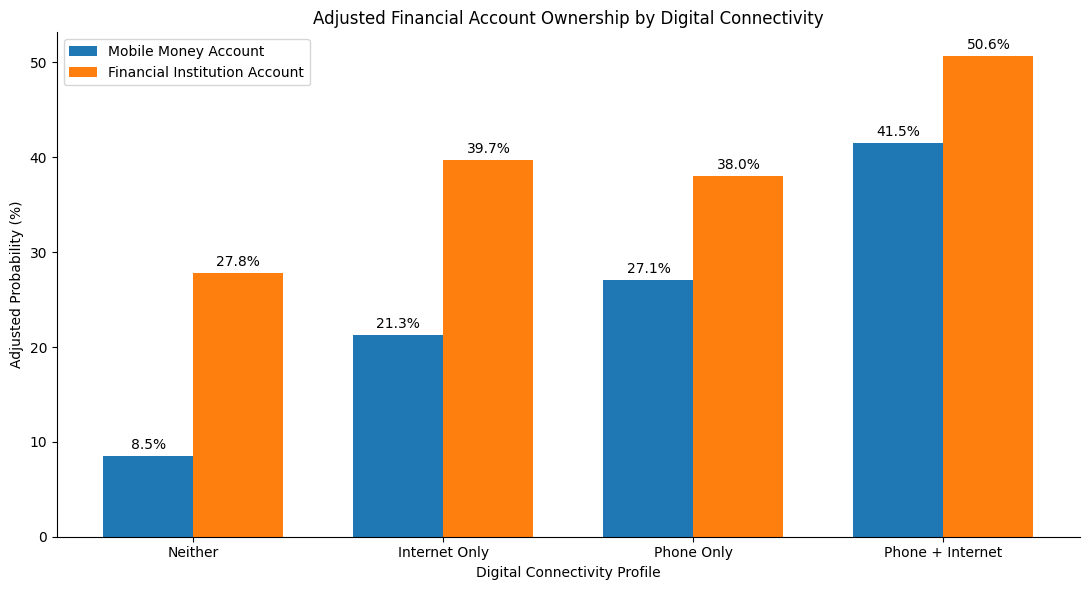

Saved to: /content/drive/MyDrive/Global_Findex_Mobile_Money_Project/outputs/connectivity_financial_inclusion_figure.png


In [44]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = interaction_table.copy()

x = np.arange(len(plot_data))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    plot_data["Mobile Money (%)"],
    width,
    label="Mobile Money Account"
)

bars2 = ax.bar(
    x + width/2,
    plot_data["Financial Institution (%)"],
    width,
    label="Financial Institution Account"
)

ax.set_ylabel("Adjusted Probability (%)")
ax.set_xlabel("Digital Connectivity Profile")
ax.set_title(
    "Adjusted Financial Account Ownership by Digital Connectivity"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Neither",
        "Internet Only",
        "Phone Only",
        "Phone + Internet"
    ]
)

ax.legend()

# Put percentages above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save permanently to Google Drive
figure_path = os.path.join(
    outputs_dir,
    "connectivity_financial_inclusion_figure.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", figure_path)

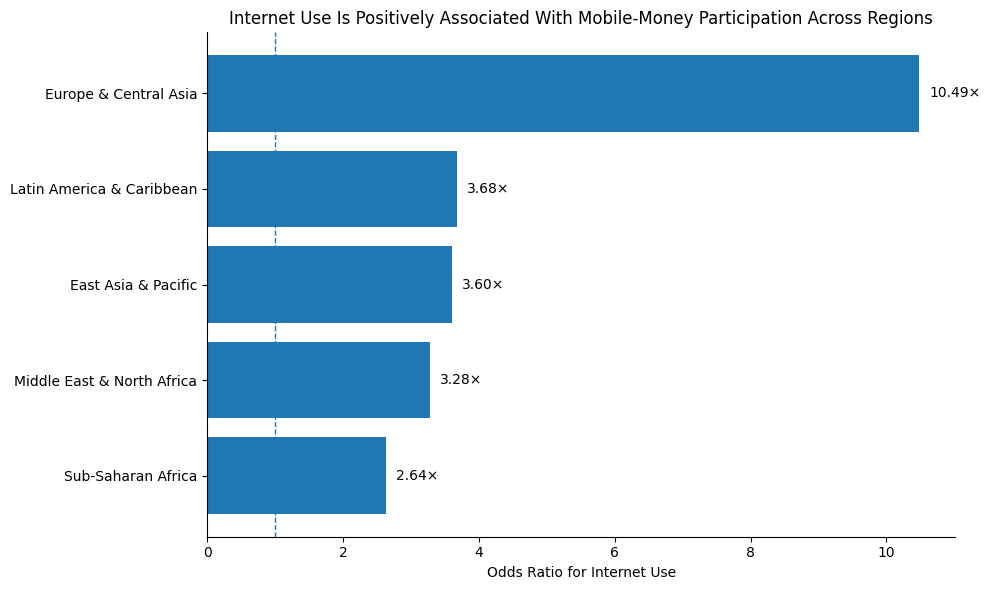

Saved to: /content/drive/MyDrive/Global_Findex_Mobile_Money_Project/outputs/regional_internet_mobile_money_figure.png


In [45]:
import matplotlib.pyplot as plt
import numpy as np

regional_plot = regional_table.copy()

# Shorter labels for readability
region_labels = {
    "Latin America & Caribbean (excluding high income)": "Latin America & Caribbean",
    "Sub-Saharan Africa (excluding high income)": "Sub-Saharan Africa",
    "Europe & Central Asia (excluding high income)": "Europe & Central Asia",
    "East Asia & Pacific (excluding high income)": "East Asia & Pacific",
    "Middle East & North Africa (excluding high income)": "Middle East & North Africa"
}

regional_plot["Region Short"] = regional_plot["Region"].map(region_labels)

# Sort by Internet odds ratio
regional_plot = regional_plot.sort_values("Internet OR")

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(regional_plot))

ax.barh(
    y,
    regional_plot["Internet OR"]
)

ax.set_yticks(y)
ax.set_yticklabels(regional_plot["Region Short"])

ax.set_xlabel("Odds Ratio for Internet Use")
ax.set_title(
    "Internet Use Is Positively Associated With Mobile-Money Participation Across Regions"
)

# OR = 1 means no association
ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1
)

for i, value in enumerate(regional_plot["Internet OR"]):
    ax.text(
        value + 0.15,
        i,
        f"{value:.2f}×",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

regional_figure_path = os.path.join(
    outputs_dir,
    "regional_internet_mobile_money_figure.png"
)

plt.savefig(
    regional_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", regional_figure_path)